In [44]:
import matplotlib.pyplot as plt
import numpy as np
from ase import io
plt.style.use("../mpl_themes/mestrado.mplstyle")

**Critérios de convergência para otimização geométrica**

~~~
vcrelax_LDA.in:etot_conv_thr = 1.0d-8
vcrelax_LDA.in:forc_conv_thr = 1.0d-4

ZnO-LDAU_12.00_7.00.in:  etot_conv_thr=1.0d-6,
ZnO-LDAU_12.00_7.00.in:  forc_conv_thr=1.0d-5,


vcrelax_PBE.in:  etot_conv_thr = 1.0d-8
vcrelax_PBE.in:  forc_conv_thr = 1.0d-4

ZnO-PBEU-9.50_7.50.in:  etot_conv_thr = 1.0d-8
ZnO-PBEU-9.50_7.50.in:  forc_conv_thr = 1.0d-4
~~~

---

**Da documentação do Quantum ESPRESSO:**



Variable-cell calculations (both optimization and dynamics) are performed with plane waves and G-vectors calculated for the starting cell.

Only the last step, after convergence has been achieved, is performed for the converged structure, with plane waves and G-vectors calculated for the final cell. $\color{yellow}{\text{Small differences between the two last steps are thus to be expected and give an estimate of the convergence of the variable-cell optimization with respect to the plane-wave basis}}$. 

A large difference means that you are far from convergence in the plane-wave basis set and you need to increase the cutoff(s) ecutwfc and/or (if applicable) ecutrho.

---

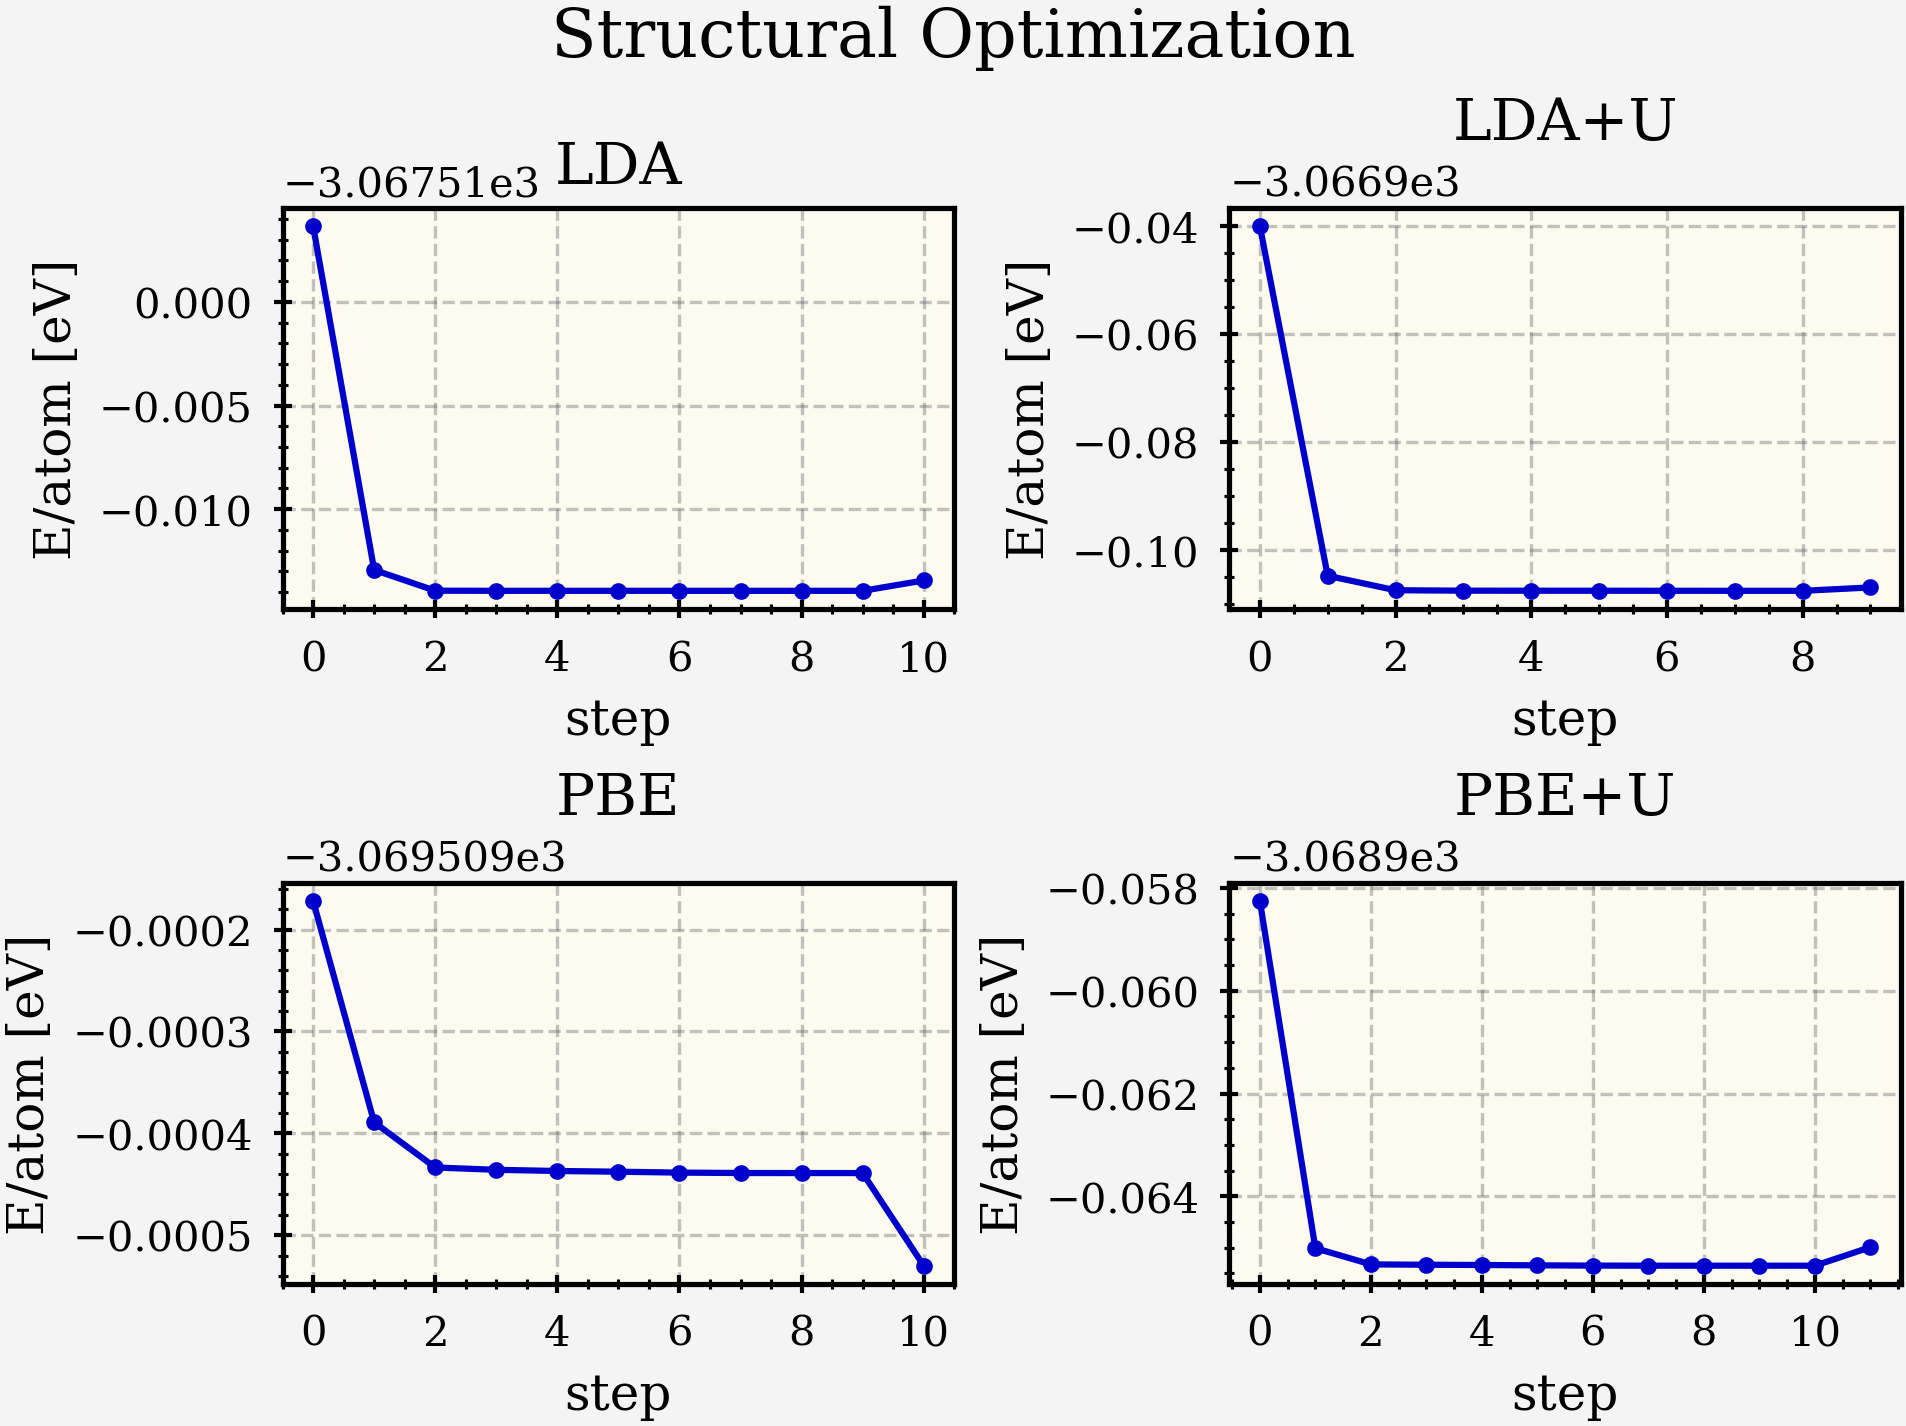

In [174]:
vc_relaxes = {
    "LDA": "/home/joaovc/ZnO_database/DFT_LDA/02_phonon_DFPT/vcrelax.out",
    "LDA+U": "/home/joaovc/ZnO_database/DFT_LDAU/01_structural_optimization/single_structure_optimization/ZnO-LDAU_12.00_7.00.out",
    "PBE": "/home/joaovc/ZnO_database/DFT_PBE/01_structural_optimization/vcrelax.out",
    "PBE+U": "/home/joaovc/ZnO_database/DFT_PBEU/01_RelaxPBEU/vcrelax-files/ZnO-PBEU-9.50_7.50.out",
}

# Images
zno_LDA = io.read(vc_relaxes["LDA"], index=":")
zno_LDAU = io.read(vc_relaxes["LDA+U"], index=":")
zno_PBE = io.read(vc_relaxes["PBE"], index=":")
zno_PBEU = io.read(vc_relaxes["PBE+U"], index=":")


titles = list(vc_relaxes.keys())
fig, axes = plt.subplots(2, 2, dpi=300, layout="constrained")
fig.suptitle("Structural Optimization", x=0.5)
ax = axes.flatten()  # list[Axes]

for i, cfg in enumerate([zno_LDA, zno_LDAU, zno_PBE, zno_PBEU]):
    energies = []

    for img in cfg:
        num_atoms = len(img)
        e = img.get_total_energy()
        energies.append(e / num_atoms)
    ax[i].set_title(titles[i])
    ax[i].set_ylabel("E/atom [eV]")
    ax[i].set_xlabel("step")
    ax[i].plot(energies, color="mediumblue", marker="o", markersize=3)
    xticks = [i for i in range(0, len(energies), 2)]
    ax[i].set_xticks(xticks)

plt.savefig("../gallery/structural_optimization_energy_profiles.pdf")
plt.show()

# Constantes de Rede

In [171]:
optimized_atoms = [img[-1] for img in [zno_LDA, zno_LDAU, zno_PBE, zno_PBEU] ]


In [ ]:

zno_LDA, zno_LDAU, zno_PBE, zno_PBEU = optimized_atoms

for i, cfg in enumerate([zno_LDA, zno_LDAU, zno_PBE, zno_PBEU]):
    # print(titles[i])
    a = cfg.cell[0][0]
    c = cfg.cell[2][2]
    covera = c / a
    scaled_positions = cfg.get_scaled_positions()
    u = scaled_positions[2, 2]
    
    print(f"{a = :.4f} | {c = :.4f} | c/a = {covera:.4f} | u = {u:.4f}")

a = 3.1962 | c = 5.1315 | c/a = 1.6055 | u = 0.3802
a = 3.1685 | c = 5.0659 | c/a = 1.5988 | u = 0.3808
a = 3.2812 | c = 5.2741 | c/a = 1.6074 | u = 0.3801
a = 3.2437 | c = 5.1890 | c/a = 1.5997 | u = 0.3808


---

## Referência Bibliográfica

<div align='center'>

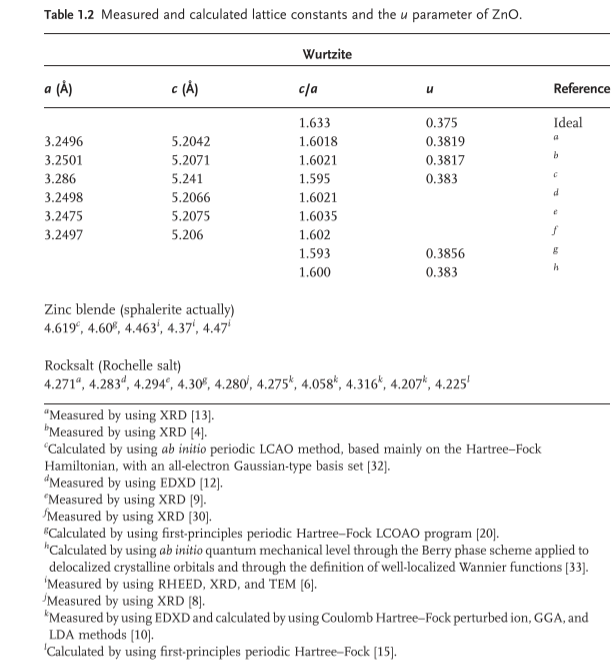

</div>